In [ ]:
## Итерация 1 Описание и тестирование
import math
import timeit
import unittest
from typing import Callable

def integrate(f: Callable[[float], float], a: float, b: float, *, n_iter: int = 100000) -> float:
    """
    Вычисляет определенный интеграл функции f на отрезке [a, b] методом левых прямоугольников.

    Аргументы:
        f (Callable[[float], float]): Интегрируемая функция.
        a (float): Нижняя граница интегрирования.
        b (float): Верхняя граница интегрирования.
        n_iter (int, optional): Количество итераций (прямоугольников). По умолчанию 100000.

    Возвращает:
        float: Приближенное значение определенного интеграла.

    Ограничения:
        Метод левых прямоугольников обладает низкой точностью (O(1/n)) по сравнению
        с методами трапеций или Симпсона. Для осциллирующих функций требуется большое n_iter.

    Пример:
        >>> import math
        >>> round(integrate(math.sin, 0, math.pi, n_iter=10000), 2)
        2.0
        >>> round(integrate(lambda x: x**2, 0, 1, n_iter=10000), 2)
        0.33
    """
    acc: float = 0.0
    step: float = (b - a) / n_iter
    for i in range(n_iter):
        acc += f(a + i * step) * step
    return acc

# Проверка doctest
import doctest
doctest.testmod(verbose=True)

class TestIntegrate(unittest.TestCase):
    def test_known_integral_sin(self):
        """Проверка известного интеграла: sin(x) от 0 до pi = 2"""
        result = integrate(math.sin, 0, math.pi, n_iter=100000)
        self.assertAlmostEqual(result, 2.0, places=4)

    def test_stability_to_iterations(self):
        """Проверка устойчивости и сходимости при увеличении n_iter"""
        res_1k = integrate(math.cos, 0, math.pi / 2, n_iter=1000)
        res_100k = integrate(math.cos, 0, math.pi / 2, n_iter=100000)
        exact_value = 1.0

        self.assertLess(abs(res_100k - exact_value), abs(res_1k - exact_value))

        self.assertAlmostEqual(res_100k, exact_value, places=4)

# Запуск тестов
unittest.main(argv=[''], verbosity=2, exit=False)

# Замеры для отчета
print("n_iter=10**4:", timeit.timeit(lambda: integrate(math.cos, 0, math.pi/2, n_iter=10**4), number=10))
print("n_iter=10**5:", timeit.timeit(lambda: integrate(math.cos, 0, math.pi/2, n_iter=10**5), number=10))
print("n_iter=10**6:", timeit.timeit(lambda: integrate(math.cos, 0, math.pi/2, n_iter=10**6), number=10))

test_known_integral_sin (__main__.TestIntegrate.test_known_integral_sin)
Проверка известного интеграла: sin(x) от 0 до pi = 2 ... ok
test_stability_to_iterations (__main__.TestIntegrate.test_stability_to_iterations)
Проверка устойчивости и сходимости при увеличении n_iter ... ok

----------------------------------------------------------------------
Ran 2 tests in 0.072s

OK


Trying:
    import math
Expecting nothing
ok
Trying:
    round(integrate(math.sin, 0, math.pi, n_iter=10000), 2)
Expecting:
    2.0
ok
Trying:
    round(integrate(lambda x: x**2, 0, 1, n_iter=10000), 2)
Expecting:
    0.33
ok
2 items had no tests:
    __main__
    __main__.measure_time
1 items passed all tests:
   3 tests in __main__.integrate
3 tests in 3 items.
3 passed and 0 failed.
Test passed.
n_iter=10**4: 0.031392949999940356
n_iter=10**5: 0.2765987519999271
n_iter=10**6: 1.4574536190000345


In [ ]:
## Итерация 2 оптимизация с помощью потоков
import concurrent.futures as futures
from functools import partial

def integrate_async_threads(f: Callable[[float], float], a: float, b: float, *, n_jobs: int = 2, n_iter: int = 100000) -> float:
    """Вычисление интеграла с использованием ThreadPoolExecutor."""
    executor = futures.ThreadPoolExecutor(max_workers=n_jobs)

    step_job: float = (b - a) / n_jobs
    iter_per_job: int = n_iter // n_jobs

    spawn = partial(executor.submit, integrate, f, n_iter=iter_per_job)

    fs = [spawn(a + i * step_job, a + (i + 1) * step_job) for i in range(n_jobs)]

    return sum(f.result() for f in futures.as_completed(fs))

# Замеры времени
for jobs in [1, 2, 4, 8]:
    t = timeit.timeit(lambda: integrate_async_threads(math.cos, 0, math.pi/2, n_jobs=jobs, n_iter=10**6), number=5)
    print(f"Threads={jobs}: {t:.4f} sec")

Threads=1: 0.5512 sec
Threads=2: 1.0857 sec
Threads=4: 1.1169 sec
Threads=8: 0.8353 sec


In [ ]:
# Итерация 3 оптимизация с помощью процессов
def integrate_async_processes(f: Callable[[float], float], a: float, b: float, *, n_jobs: int = 2, n_iter: int = 100000) -> float:
    """Вычисление интеграла с использованием ProcessPoolExecutor."""
    # для процессов функция f должна быть pickle-совместимой
    # lambda-функции через процессы не передаются
    with futures.ProcessPoolExecutor(max_workers=n_jobs) as executor:
        step_job: float = (b - a) / n_jobs
        iter_per_job: int = n_iter // n_jobs

        spawn = partial(executor.submit, integrate, f, n_iter=iter_per_job)
        fs = [spawn(a + i * step_job, a + (i + 1) * step_job) for i in range(n_jobs)]

        return sum(f.result() for f in futures.as_completed(fs))

# Замеры времени
for jobs in [1, 2, 4, 8]:
    t = timeit.timeit(lambda: integrate_async_processes(math.cos, 0, math.pi/2, n_jobs=jobs, n_iter=10**6), number=5)
    print(f"Processes={jobs}: {t:.4f} sec")

Processes=1: 0.8366 sec
Processes=2: 0.9444 sec
Processes=4: 2.2518 sec
Processes=8: 2.6969 sec


In [ ]:
# Итерация 4 Cython
!pip install cython
%load_ext Cython

The Cython extension is already loaded. To reload it, use:
  %reload_ext Cython


In [ ]:
%%cython -a

from libc.math cimport cos

def integrate_cython_optimized(double a, double b, int n_iter=100000):
    """
    Оптимизированная версия Cython.
    """
    cdef double acc = 0.0
    cdef double step = (b - a) / n_iter
    cdef int i
    cdef double x

    for i in range(n_iter):
        x = a + i * step
        acc += cos(x) * step

    return acc

In [ ]:
# Итерация 5 noGill
%%cython -a --compile-args=-fopenmp --link-args=-fopenmp
from libc.math cimport cos
from cython.parallel cimport prange

def integrate_cython_nogil(double a, double b, int n_iter=100000, int n_jobs=4):
    cdef double acc = 0.0
    cdef double step = (b - a) / n_iter
    cdef int i
    cdef double x

    # prange автоматически распараллеливает цикл по потокам C-уровня,
    # полностью обходя Python GIL. Cython сам сделает reduction для acc.
    for i in prange(n_iter, nogil=True, num_threads=n_jobs):
        x = a + i * step
        acc += cos(x) * step
    return acc

Идут замеры времени... Это может занять пару минут...
Замеры завершены

--- Итоговая таблица производительности ---


,Метод оптимизации,Время (сек),Ускорение (Speedup)
0,1. Python (Base),0.13675,1.00x
1,2. Threads (2 jobs),0.11376,1.20x
2,2. Threads (4 jobs),0.11233,1.22x
3,3. Processes (2 jobs),0.15577,0.88x
4,3. Processes (4 jobs),0.18574,0.74x
5,4. Cython (1 thread),0.01257,10.88x
6,5. Cython noGIL (2 threads),0.01139,12.01x
7,5. Cython noGIL (4 threads),0.01118,12.23x


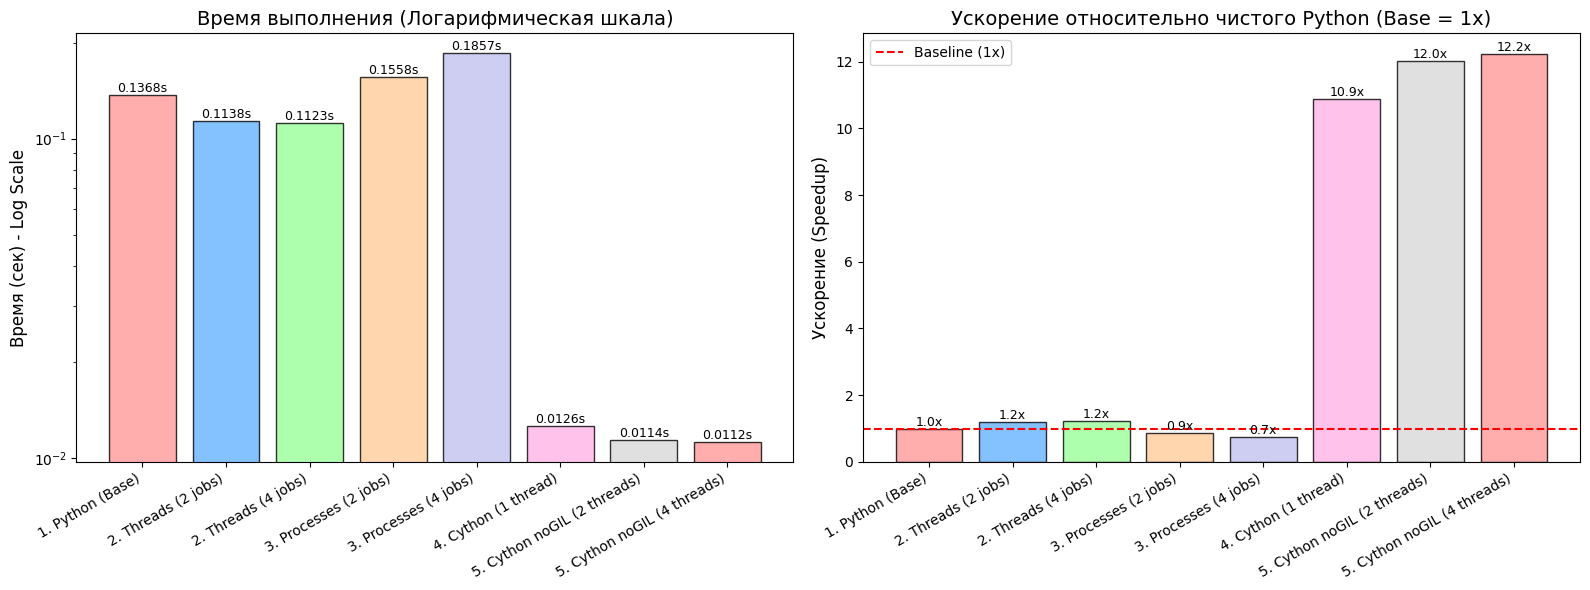

In [ ]:
import timeit
import math
import matplotlib.pyplot as plt
import pandas as pd

# Параметры для тестирования
a, b = 0, math.pi / 2
n_iter = 10**6  # 1 миллион итераций: достаточно для наглядности, но не заставит ждать вечность

def measure_time(func, *args, **kwargs):
    """Вспомогательная функция: прогрев и замер среднего времени"""
    func(*args, **kwargs)  # Прогрев (Warm-up), чтобы исключить накладные расходы на первый запуск
    t = timeit.timeit(lambda: func(*args, **kwargs), number=5)
    return t / 5  # Возвращаем среднее время одного запуска

results = {}

print("Идут замеры времени... Это может занять пару минут...")

# 1. Итерация 1: Чистый Python
results['1. Python (Base)'] = measure_time(integrate, math.cos, a, b, n_iter=n_iter)

# 2. Итерация 2: Потоки (Threads)
for jobs in [2, 4]:
    results[f'2. Threads ({jobs} jobs)'] = measure_time(
        integrate_async_threads, math.cos, a, b, n_jobs=jobs, n_iter=n_iter
    )

# 3. Итерация 3: Процессы (Processes)
for jobs in [2, 4]:
    results[f'3. Processes ({jobs} jobs)'] = measure_time(
        integrate_async_processes, math.cos, a, b, n_jobs=jobs, n_iter=n_iter
    )

# 4. Итерация 4: Cython (1 поток)
# Примечание: в оптимизированном Cython мы зашили cos внутри, поэтому не передаем f
results['4. Cython (1 thread)'] = measure_time(
    integrate_cython_optimized, a, b, n_iter=n_iter
)

# 5. Итерация 5: Cython noGIL (OpenMP)
for jobs in [2, 4]:
    results[f'5. Cython noGIL ({jobs} threads)'] = measure_time(
        integrate_cython_nogil, a, b, n_iter=n_iter, n_jobs=jobs
    )

print("Замеры завершены\n")

# --- Обработка данных и Отчет ---
methods = list(results.keys())
times = list(results.values())
base_time = times[0]
speedups = [base_time / t for t in times]

# 1. Красивая таблица для отчета
df = pd.DataFrame({
    'Метод оптимизации': methods,
    'Время (сек)': [f"{t:.5f}" for t in times],
    'Ускорение (Speedup)': [f"{s:.2f}x" for s in speedups]
})
print("--- Итоговая таблица производительности ---")
display(df)
print("\n")

# 2. Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0', '#ffb3e6', '#d9d9d9']

# График 1: Время выполнения (Логарифмическая шкала)
bars1 = ax1.bar(methods, times, color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Время (сек) - Log Scale', fontsize=12)
ax1.set_yscale('log')  # Логарифмическая шкала обязательна из-за огромной разницы
ax1.set_title('Время выполнения (Логарифмическая шкала)', fontsize=14)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=30, ha='right')
# Подписываем точное время над каждым столбиком
for bar, t in zip(bars1, times):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{t:.4f}s',
             ha='center', va='bottom', fontsize=9)

# График 2: Ускорение (Speedup относительно чистого Python)
bars2 = ax2.bar(methods, speedups, color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Ускорение (Speedup)', fontsize=12)
ax2.set_title('Ускорение относительно чистого Python (Base = 1x)', fontsize=14)
ax2.set_xticks(range(len(methods)))
ax2.set_xticklabels(methods, rotation=30, ha='right')
ax2.axhline(1.0, color='red', linestyle='--', label='Baseline (1x)')
ax2.legend()
for bar, s in zip(bars2, speedups):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{s:.1f}x',
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()